# Unconstrained GMV — Four-Strategy Comparison (Pure-RIENet added)

**Goal**: Compare four GMV strategies with **unconstrained** weights so that
the only difference is the quality of the covariance estimate.

## Formula (unconstrained analytical GMV)
$$w^* = \\frac{\\Sigma^{-1} \\mathbf{1}}{\\mathbf{1}^\\top \\Sigma^{-1} \\mathbf{1}}$$

Weights can be negative (short positions). No cap constraint.

## Strategies compared
1. **GMV-GARCH** — GARCH(1,1) vols + rolling correlation — analytical inverse
2. **GMV-NN** — CNN-GARCH vols + rolling correlation — analytical inverse
3. **GMV-NN-Clean** — CNN-GARCH vols + RIENet-cleaned eigen decomposition — `EigenWeightsLayer`
4. **Pure-RIENet** — Rolling realized vol (90-day std) + RIENet-cleaned eigen decomposition — `EigenWeightsLayer`

All four use the same unconstrained analytical solution for a fair comparison.
**Pure-RIENet** requires no neural network inference — only rolling statistics + eigen shrinkage.


In [1]:
from __future__ import annotations
import warnings, sys, time
import numpy as np
import pandas as pd
import torch
import tensorflow as tf
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

from model import HybridGarch
from data_stocks_WIKI_price import get_cleaned_data
from rienet_torch import CorrelationEigenTransformLayer, EigenWeightsLayer

print(f'TensorFlow {tf.__version__} | NumPy {np.__version__} | PyTorch {torch.__version__}')


TensorFlow 2.20.0 | NumPy 1.26.4 | PyTorch 2.10.0+cpu


In [2]:
pip install rienet_torch


Note: you may need to restart the kernel to use updated packages.


In [3]:
# ── Configuration ──────────────────────────────────────────────────────────────────────────────────
FILE_PATH   = r'C:/Users/karim/OneDrive/Documents/Msc AI/Finance/TP/WIKI_PRICES_212b326a081eacca455e13140d7bb9db.zip'
CHECKPOINT  = r'../finetune_real_zeroaware_r2min1e8_best.weights.h5'

WINDOW_SIZE = 90      # rolling window — CNN input & correlation window
N_STOCKS    = 50
TRAIN_RATIO = 0.70
ANNUALIZE   = 252

# Blending ratio for RIENet strategies:
#   0.0 = raw sample correlation only  (like GMV-GARCH / GMV-NN -> ~45% short)
#   1.0 = fully cleaned correlation    (0% short, dominated by market factor)
#   0.5 = blended: preserves some noise structure -> allows short positions
BLEND_ALPHA = 0.5

print(f'Window : {WINDOW_SIZE} | Unconstrained GMV | RIENet blend alpha = {BLEND_ALPHA}')


Window : 90 | Unconstrained GMV | RIENet blend alpha = 0.5


## 1. Data Loading

In [4]:
returns_df_full = get_cleaned_data(FILE_PATH)
print(f'Full universe : {returns_df_full.shape[0]} days x {returns_df_full.shape[1]} stocks')
print(f'Date range    : {returns_df_full.index[0].date()} -> {returns_df_full.index[-1].date()}')

# Select first N_STOCKS (same as Portfolio.ipynb)
selected   = returns_df_full.columns[:N_STOCKS].tolist()
returns_df = returns_df_full[selected].copy()
print(f'\nPortfolio : {N_STOCKS} stocks -> {selected[:5]} ...')

[get_cleaned_data] Universe after filters : 1338 stocks (price≥$3.0 on 2012-10-04, max consec zeros ≤ 20)


Full universe : 4585 days x 1338 stocks
Date range    : 2000-01-04 -> 2018-03-27

Portfolio : 50 stocks -> ['A', 'AAN', 'AAON', 'AAPL', 'ABAX'] ...


## 2. Train / Test Split

In [5]:
n_total   = len(returns_df)
split_idx = int(TRAIN_RATIO * n_total)
start_t   = max(WINDOW_SIZE, split_idx)

returns_train = returns_df.iloc[:split_idx]
returns_test  = returns_df.iloc[split_idx:]
test_dates    = returns_df.index[start_t:]

returns_arr  = returns_df.values.astype(np.float32)   # [T, N]
train_means  = returns_train.mean().values.astype(np.float32)
train_stds   = returns_train.std(ddof=0).values.astype(np.float32)

print(f'Train : {returns_train.index[0].date()} -> {returns_train.index[-1].date()} ({len(returns_train)} days)')
print(f'Test  : {returns_test.index[0].date()}  -> {returns_test.index[-1].date()}  ({len(returns_test)} days)')
print(f'start_t = {start_t} | test_len = {len(test_dates)}')

Train : 2000-01-04 -> 2012-10-03 (3209 days)
Test  : 2012-10-04  -> 2018-03-27  (1376 days)
start_t = 3209 | test_len = 1376


## 3. Load CNN-GARCH Model

In [6]:
model = HybridGarch(hidden=32, kernel=3, conv_layers=5)
# Build the model with a dummy input so weights are created before loading
dummy_input = tf.zeros((1, WINDOW_SIZE, 1))
_ = model(dummy_input, training=False)
model.load_weights(CHECKPOINT)
print(f'Model loaded : {model.count_params():,} parameters')

Model loaded : 14,499 parameters


## 4. Volatility Estimation Functions

In [7]:
def _predict_nn_batch(windows_norm, model):
    x = tf.constant(windows_norm, dtype=tf.float32)
    x = tf.expand_dims(x, axis=-1)
    sigma2_norm, _, _, _ = model(x, training=False)
    return sigma2_norm.numpy()


def precompute_sigma2_nn(returns_arr, train_means, train_stds, model,
                         window_size, start_t, annualize=252):
    T, N = returns_arr.shape
    sigma2_mat = np.full((T - start_t, N), np.nan)
    eps = 1e-8
    for k, t in enumerate(range(start_t, T)):
        windows = returns_arr[t - window_size:t, :]
        if np.isnan(windows).any():
            continue
        wn = (windows.T - train_means[:, None]) / (train_stds[:, None] + eps)
        s2 = _predict_nn_batch(wn, model) * (train_stds + eps) ** 2
        sigma2_mat[k] = np.clip(s2, 1e-10, None) * annualize
    return sigma2_mat


def precompute_sigma2_arch(returns_arr, train_means, split_idx, start_t, annualize=252):
    from arch import arch_model as arch_fit
    T, N = returns_arr.shape
    sigma2_mat = np.zeros((T - start_t, N))
    for j in range(N):
        r_j = returns_arr[:split_idx, j].astype(np.float64)
        try:
            res = arch_fit(r_j * 100, mean='Zero', vol='GARCH', p=1, q=1).fit(disp='off')
            omega = res.params['omega'] / 1e4
            alpha = res.params['alpha[1]']
            beta  = res.params['beta[1]']
            s2    = float(res.conditional_volatility[-1] ** 2)
        except Exception:
            omega, alpha, beta = 1e-6, 0.05, 0.90
            s2 = np.var(r_j, ddof=0)
        for t in range(split_idx, T):
            s2 = omega + alpha * returns_arr[t-1, j]**2 + beta * s2
            s2 = max(s2, 1e-10)
            if t >= start_t:
                sigma2_mat[t - start_t, j] = s2 * annualize
    return sigma2_mat


def precompute_sigma2_realized(returns_arr, start_t, window_size, annualize=252):
    """Rolling realized variance: sample variance over the past window_size days.
    No model inference required.
    """
    T, N = returns_arr.shape
    sigma2_mat = np.full((T - start_t, N), np.nan)
    for k, t in enumerate(range(start_t, T)):
        window = returns_arr[t - window_size:t, :]
        sigma2_mat[k] = np.var(window, axis=0, ddof=1) * annualize
    return sigma2_mat


print('Volatility functions defined (nn / arch / realized).')


Volatility functions defined (nn / arch / realized).


## 5. Compute Sigma² Matrices

In [8]:
print('[1/3] CNN-GARCH forward pass...')
t0 = time.time()
sigma2_nn = precompute_sigma2_nn(
    returns_arr, train_means, train_stds, model, WINDOW_SIZE, start_t, ANNUALIZE
)
print(f'      OK ({time.time()-t0:.1f}s)')

print('[2/3] GARCH(1,1) recursion...')
t0 = time.time()
sigma2_arch = precompute_sigma2_arch(
    returns_arr.astype(np.float64), train_means, split_idx, start_t, ANNUALIZE
)
print(f'      OK ({time.time()-t0:.1f}s)')

print('[3/3] Rolling realized variance...')
t0 = time.time()
sigma2_realized = precompute_sigma2_realized(
    returns_arr, start_t, WINDOW_SIZE, ANNUALIZE
)
print(f'      OK ({time.time()-t0:.1f}s)')

print(f'\nShape: {sigma2_nn.shape}  [test_days x N_stocks]')


[1/3] CNN-GARCH forward pass...


      OK (218.3s)
[2/3] GARCH(1,1) recursion...


      OK (4.0s)
[3/3] Rolling realized variance...
      OK (0.1s)

Shape: (1376, 50)  [test_days x N_stocks]


## 6. GMV Portfolio Optimization

### Unconstrained Analytical Solution

At each day $t$:
$$\Sigma(t) = D(t) \cdot \hat{C}_{t-90:t} \cdot D(t)$$
$$w^*(t) = \frac{\Sigma(t)^{-1} \mathbf{1}}{\mathbf{1}^\top \Sigma(t)^{-1} \mathbf{1}}$$

- **GMV-GARCH / GMV-NN**: direct matrix inversion (Cholesky solve)
- **GMV-NN-Clean**: `EigenWeightsLayer` on RIENet-cleaned eigendecomposition


In [9]:
def rolling_correlation(returns_arr, t, window_size):
    """Sample correlation matrix from returns[t-window:t]."""
    window = returns_arr[t - window_size:t, :]
    w = window - window.mean(axis=0)
    cov = (w.T @ w) / (window_size - 1)
    std = np.maximum(np.sqrt(np.diag(cov)), 1e-10)
    corr = cov / np.outer(std, std)
    corr = np.clip(corr, -1.0, 1.0)
    np.fill_diagonal(corr, 1.0)
    return corr


def nearest_psd(cov, reg=1e-6):
    """Clip negative eigenvalues -> guaranteed PSD."""
    cov = (cov + cov.T) / 2
    eigvals, eigvecs = np.linalg.eigh(cov)
    eigvals = np.maximum(eigvals, reg)
    cov_psd = eigvecs @ np.diag(eigvals) @ eigvecs.T
    return (cov_psd + cov_psd.T) / 2


# ── RIENet layer ───────────────────────────────────────────────────────────────────────
corr_cleaner = CorrelationEigenTransformLayer(name='corr_cleaner')
print('RIENet layer ready: CorrelationEigenTransformLayer')


def build_covariance(sigma2_daily, corr):
    """Build covariance from vols + rolling correlation."""
    sigma_daily = np.sqrt(np.maximum(sigma2_daily / ANNUALIZE, 1e-10))
    D = np.diag(sigma_daily)
    return nearest_psd(D @ corr @ D)


def gmv_weights_unconstrained(cov):
    """Analytical unconstrained GMV via Cholesky solve. Weights can be negative."""
    N = cov.shape[0]
    ones = np.ones(N)
    cov_psd = nearest_psd(cov)
    try:
        L = np.linalg.cholesky(cov_psd)
        z = np.linalg.solve(L, ones)
        w = np.linalg.solve(L.T, z)
    except np.linalg.LinAlgError:
        w = np.linalg.pinv(cov_psd) @ ones
    denom = w.sum()
    if abs(denom) < 1e-10:
        return ones / N
    return w / denom


def gmv_weights_rienet(sigma2_daily, corr_raw, corr_layer,
                        q=None, lookback=None, blend_alpha=BLEND_ALPHA):
    """Unconstrained GMV on a blended covariance: (1-alpha)*C_raw + alpha*C_clean.

    blend_alpha=1.0 -> fully RIENet-cleaned (0% short)
    blend_alpha=0.0 -> raw sample correlation (same as Cholesky GMV)
    blend_alpha=0.5 -> partial cleaning; retains some noise -> allows short positions
    """
    N = len(sigma2_daily)
    sigma_daily = np.sqrt(np.maximum(sigma2_daily / ANNUALIZE, 1e-10))

    corr_t = torch.tensor(corr_raw[np.newaxis], dtype=torch.float32)   # (1, N, N)
    attr_cols = []
    if q is not None:
        attr_cols.append(float(q))
    if lookback is not None:
        attr_cols.append(float(lookback))
    attrs = torch.tensor([attr_cols], dtype=torch.float32) if attr_cols else None

    # RIENet-cleaned correlation
    corr_clean = corr_layer(
        corr_t, attributes=attrs, output_type='correlation'
    )
    corr_clean_np = corr_clean[0].detach().numpy()  # (N, N)

    # Blend: (1-alpha)*raw + alpha*clean
    corr_eff = (1.0 - blend_alpha) * corr_raw + blend_alpha * corr_clean_np
    np.fill_diagonal(corr_eff, 1.0)   # ensure unit diagonal

    # Build covariance and solve GMV
    cov = build_covariance(sigma2_daily, corr_eff)
    return gmv_weights_unconstrained(cov)


print('GMV functions defined (all unconstrained, weights can be negative).')
print(f'  GMV-GARCH / GMV-NN  : Cholesky on raw sample covariance')
print(f'  GMV-NN-Clean        : Cholesky on blended covariance (alpha={BLEND_ALPHA})')
print(f'  Pure-RIENet         : Cholesky on blended covariance (alpha={BLEND_ALPHA})')


RIENet layer ready: CorrelationEigenTransformLayer
GMV functions defined (all unconstrained, weights can be negative).
  GMV-GARCH / GMV-NN  : Cholesky on raw sample covariance
  GMV-NN-Clean        : Cholesky on blended covariance (alpha=0.5)
  Pure-RIENet         : Cholesky on blended covariance (alpha=0.5)


In [10]:
def compute_gmv_portfolio(sigma2_mat, returns_arr, start_t, window_size,
                          label='GMV', corr_layer=None):
    """Compute daily GMV portfolio returns and weights (unconstrained).

    GMV-GARCH / GMV-NN  : Cholesky on raw sample covariance.
    GMV-NN-Clean / Pure-RIENet : Cholesky on RIENet-cleaned covariance.
    """
    test_len   = sigma2_mat.shape[0]
    N          = sigma2_mat.shape[1]
    q_ratio    = window_size / N
    use_rienet = corr_layer is not None
    port_returns = np.zeros(test_len)
    weights_hist = np.zeros((test_len, N))

    for k in range(test_len):
        t    = start_t + k
        r_t  = returns_arr[t]
        s2_k = sigma2_mat[k]

        if np.isnan(s2_k).any():
            w = np.ones(N) / N
        elif use_rienet:
            corr = rolling_correlation(returns_arr, t, window_size)
            w = gmv_weights_rienet(
                s2_k, corr,
                corr_layer=corr_layer,
                q=q_ratio, lookback=float(window_size),
            )
        else:
            corr = rolling_correlation(returns_arr, t, window_size)
            cov  = build_covariance(s2_k, corr)
            w    = gmv_weights_unconstrained(cov)

        port_returns[k] = np.dot(w, r_t)
        weights_hist[k] = w

        if k % 200 == 0:
            short_pct = (w < 0).mean() * 100
            print(f'  [{label}] Day {k}/{test_len} — short={short_pct:.0f}% HHI={(w**2).sum():.3f}')

    return port_returns, weights_hist


print('compute_gmv_portfolio defined (unconstrained, RIENet via inverse_correlation).')


compute_gmv_portfolio defined (unconstrained, RIENet via inverse_correlation).


## 7. Run All Strategies

In [11]:
print('Computing unconstrained strategies...')

print('  [1/4] GMV-GARCH...')
t0 = time.time()
r_gmv_arch, w_gmv_arch = compute_gmv_portfolio(
    sigma2_arch, returns_arr, start_t, WINDOW_SIZE, label='GMV-GARCH'
)
print(f'        Done ({time.time()-t0:.0f}s)')

print('  [2/4] GMV-NN...')
t0 = time.time()
r_gmv_nn, w_gmv_nn = compute_gmv_portfolio(
    sigma2_nn, returns_arr, start_t, WINDOW_SIZE, label='GMV-NN'
)
print(f'        Done ({time.time()-t0:.0f}s)')

print('  [3/4] GMV-NN-Clean...')
t0 = time.time()
r_gmv_nn_clean, w_gmv_nn_clean = compute_gmv_portfolio(
    sigma2_nn, returns_arr, start_t, WINDOW_SIZE,
    label='GMV-NN-Clean',
    corr_layer=corr_cleaner,
)
print(f'        Done ({time.time()-t0:.0f}s)')

print('  [4/4] Pure-RIENet (realized vol + RIENet inverse corr)...')
t0 = time.time()
r_gmv_pure_rienet, w_gmv_pure_rienet = compute_gmv_portfolio(
    sigma2_realized, returns_arr, start_t, WINDOW_SIZE,
    label='Pure-RIENet',
    corr_layer=corr_cleaner,
)
print(f'        Done ({time.time()-t0:.0f}s)')

print('\nAll strategies computed.')


Computing unconstrained strategies...
  [1/4] GMV-GARCH...
  [GMV-GARCH] Day 0/1376 — short=42% HHI=0.531


  [GMV-GARCH] Day 200/1376 — short=44% HHI=0.317


  [GMV-GARCH] Day 400/1376 — short=52% HHI=0.620


  [GMV-GARCH] Day 600/1376 — short=50% HHI=0.862


  [GMV-GARCH] Day 800/1376 — short=48% HHI=1.187


...

  [Pure-RIENet] Day 600/1376 — short=30% HHI=0.111


  [Pure-RIENet] Day 800/1376 — short=38% HHI=0.135


  [Pure-RIENet] Day 1000/1376 — short=34% HHI=0.090


  [Pure-RIENet] Day 1200/1376 — short=32% HHI=0.086


        Done (127s)

All strategies computed.


## 8. Financial Metrics

In [12]:
def financial_metrics(returns, annualize=252):
    r = pd.Series(returns).dropna()
    ann_ret = r.mean() * annualize
    ann_vol = r.std(ddof=0) * np.sqrt(annualize)
    sharpe  = ann_ret / ann_vol if ann_vol > 1e-10 else np.nan
    cumret  = (1 + r).cumprod()
    max_dd  = float(((cumret - cumret.cummax()) / cumret.cummax()).min())
    calmar  = ann_ret / abs(max_dd) if abs(max_dd) > 1e-10 else np.nan
    return {
        'Ann. Return (%)' : round(ann_ret * 100, 2),
        'Ann. Vol (%)'    : round(ann_vol * 100, 2),
        'Sharpe'          : round(sharpe, 4),
        'Max Drawdown (%)': round(max_dd * 100, 2),
        'Calmar'          : round(calmar, 4),
    }


metrics = pd.DataFrame({
    'GMV-GARCH'    : financial_metrics(r_gmv_arch),
    'GMV-NN'       : financial_metrics(r_gmv_nn),
    'GMV-NN-Clean' : financial_metrics(r_gmv_nn_clean),
    'Pure-RIENet'  : financial_metrics(r_gmv_pure_rienet),
}).T

print('=' * 60)
print('OUT-OF-SAMPLE PERFORMANCE')
print('=' * 60)
print(metrics.to_string())
print()

best_vol    = metrics['Ann. Vol (%)'].idxmin()
best_sharpe = metrics['Sharpe'].idxmax()
best_dd     = metrics['Max Drawdown (%)'].idxmax()
print(f'Best Volatility  : {best_vol}')
print(f'Best Sharpe      : {best_sharpe}')
print(f'Best Max Drawdown: {best_dd}')


OUT-OF-SAMPLE PERFORMANCE
              Ann. Return (%)  Ann. Vol (%)  Sharpe  Max Drawdown (%)  Calmar
GMV-GARCH               17.39         13.95  1.2468            -13.21  1.3165
GMV-NN                  20.43         14.40  1.4190            -17.37  1.1761
GMV-NN-Clean            16.60         10.54  1.5758            -15.16  1.0953
Pure-RIENet             15.40         10.35  1.4877            -11.42  1.3480

Best Volatility  : Pure-RIENet
Best Sharpe      : GMV-NN-Clean
Best Max Drawdown: Pure-RIENet


## 9. Visualizations (includes short-weight diagnostic)


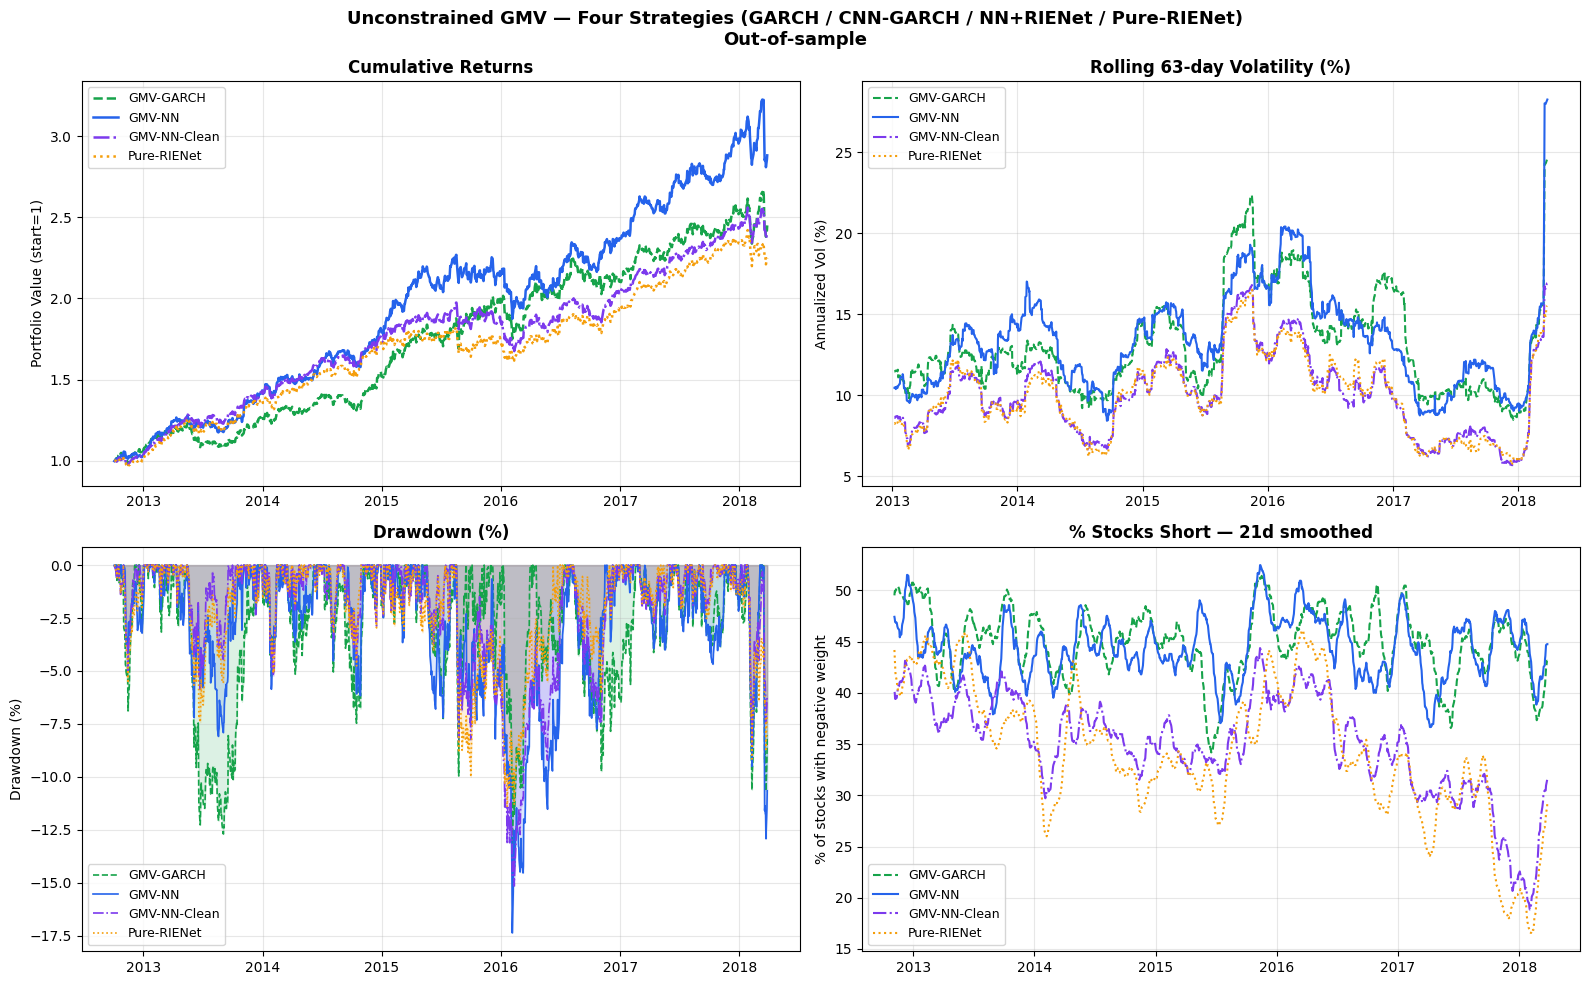

Figure saved: gmv_unconstrained_4strategies.png


In [13]:
_BLUE   = '#2563EB'
_GREEN  = '#16A34A'
_PURPLE = '#7C3AED'
_ORANGE = '#F59E0B'

strategies = {
    'GMV-GARCH'    : (r_gmv_arch,         w_gmv_arch,         _GREEN,  '--'),
    'GMV-NN'       : (r_gmv_nn,           w_gmv_nn,           _BLUE,   '-'),
    'GMV-NN-Clean' : (r_gmv_nn_clean,     w_gmv_nn_clean,     _PURPLE, '-.'),
    'Pure-RIENet'  : (r_gmv_pure_rienet,  w_gmv_pure_rienet,  _ORANGE, ':'),
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    'Unconstrained GMV — Four Strategies (GARCH / CNN-GARCH / NN+RIENet / Pure-RIENet)\nOut-of-sample',
    fontsize=13, fontweight='bold'
)

ax = axes[0, 0]
for name, (r, w, col, ls) in strategies.items():
    cum = (1 + pd.Series(r, index=test_dates)).cumprod()
    ax.plot(cum.index, cum.values, color=col, linestyle=ls, linewidth=1.8, label=name)
ax.set_title('Cumulative Returns', fontweight='bold')
ax.set_ylabel('Portfolio Value (start=1)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[0, 1]
for name, (r, w, col, ls) in strategies.items():
    roll_vol = pd.Series(r, index=test_dates).rolling(63).std() * np.sqrt(252) * 100
    ax.plot(roll_vol.index, roll_vol.values, color=col, linestyle=ls, linewidth=1.5, label=name)
ax.set_title('Rolling 63-day Volatility (%)', fontweight='bold')
ax.set_ylabel('Annualized Vol (%)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1, 0]
for name, (r, w, col, ls) in strategies.items():
    cum = (1 + pd.Series(r, index=test_dates)).cumprod()
    dd  = (cum - cum.cummax()) / cum.cummax() * 100
    ax.fill_between(dd.index, dd.values, 0, alpha=0.15, color=col)
    ax.plot(dd.index, dd.values, color=col, linestyle=ls, linewidth=1.2, label=name)
ax.set_title('Drawdown (%)', fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1, 1]
for name, (r, w, col, ls) in strategies.items():
    short_pct = pd.Series((w < 0).mean(axis=1) * 100, index=test_dates)
    ax.plot(short_pct.index, short_pct.rolling(21).mean(),
            color=col, linestyle=ls, linewidth=1.5, label=name)
ax.set_title('% Stocks Short — 21d smoothed', fontweight='bold')
ax.set_ylabel('% of stocks with negative weight')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('gmv_unconstrained_4strategies.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: gmv_unconstrained_4strategies.png')


In [14]:
N_STOCKS

50

## 10. Full Comparison — All 4 Strategies


In [15]:
all_strategies = {
    'GMV-GARCH'    : (r_gmv_arch,         w_gmv_arch),
    'GMV-NN'       : (r_gmv_nn,           w_gmv_nn),
    'GMV-NN-Clean' : (r_gmv_nn_clean,     w_gmv_nn_clean),
    'Pure-RIENet'  : (r_gmv_pure_rienet,  w_gmv_pure_rienet),
}

all_metrics = {name: financial_metrics(r) for name, (r, _) in all_strategies.items()}

print('=' * 90)
print('FULL COMPARISON — UNCONSTRAINED GMV (Out-of-sample)')
print('=' * 90)

header = f"{'Metric':<22}" + ''.join(f'{name:>16}' for name in all_metrics)
print(header)
print('-' * len(header))

metric_names = list(next(iter(all_metrics.values())).keys())
for m in metric_names:
    vals = [all_metrics[name][m] for name in all_metrics]
    row = f'{m:<22}' + ''.join(f'{v:>16}' for v in vals)
    best_name = (min if ('Vol' in m or 'Drawdown' in m) else max)(
        all_metrics, key=lambda n: all_metrics[n][m])
    print(row + f'   <- best: {best_name}')

print(f'\n{"-" * 90}')
print(f'{"SHORT-WEIGHT DIAGNOSTICS":<22}' + ''.join(f'{name:>16}' for name in all_strategies))
print('-' * 90)

short_row   = f'{"Mean % stocks short":<22}'
max_lvg_row = f'{"Mean gross leverage":<22}'
for name, (_, w) in all_strategies.items():
    short_pct = (w < 0).mean(axis=1).mean() * 100
    gross_lev = np.abs(w).sum(axis=1).mean()
    short_row   += f'{short_pct:>15.1f}%'
    max_lvg_row += f'{gross_lev:>16.3f}'

print(short_row)
print(max_lvg_row)

print(f'\n{"=" * 90}')
print('EFFECT OF RIENet CLEANING (Pure-RIENet vs GMV-GARCH)')
print('=' * 90)
m_base = all_metrics['GMV-GARCH']
m_pure = all_metrics['Pure-RIENet']
for k in metric_names:
    v1, v2 = m_base[k], m_pure[k]
    if 'Vol' in k or 'Drawdown' in k:
        imp = f'{v1 - v2:+.2f}  (lower is better)' if v2 < v1 else f'{v1 - v2:+.2f}'
    else:
        imp = f'{v2 - v1:+.4f}  (higher is better)' if v2 > v1 else f'{v2 - v1:+.4f}'
    print(f'  {k:<22} {imp}')


FULL COMPARISON — UNCONSTRAINED GMV (Out-of-sample)
Metric                       GMV-GARCH          GMV-NN    GMV-NN-Clean     Pure-RIENet
--------------------------------------------------------------------------------------
Ann. Return (%)                  17.39           20.43            16.6            15.4   <- best: GMV-NN
Ann. Vol (%)                     13.95            14.4           10.54           10.35   <- best: Pure-RIENet
Sharpe                          1.2468           1.419          1.5758          1.4877   <- best: GMV-NN-Clean
Max Drawdown (%)                -13.21          -17.37          -15.16          -11.42   <- best: GMV-NN
Calmar                          1.3165          1.1761          1.0953           1.348   <- best: Pure-RIENet

------------------------------------------------------------------------------------------
SHORT-WEIGHT DIAGNOSTICS       GMV-GARCH          GMV-NN    GMV-NN-Clean     Pure-RIENet
----------------------------------------------------

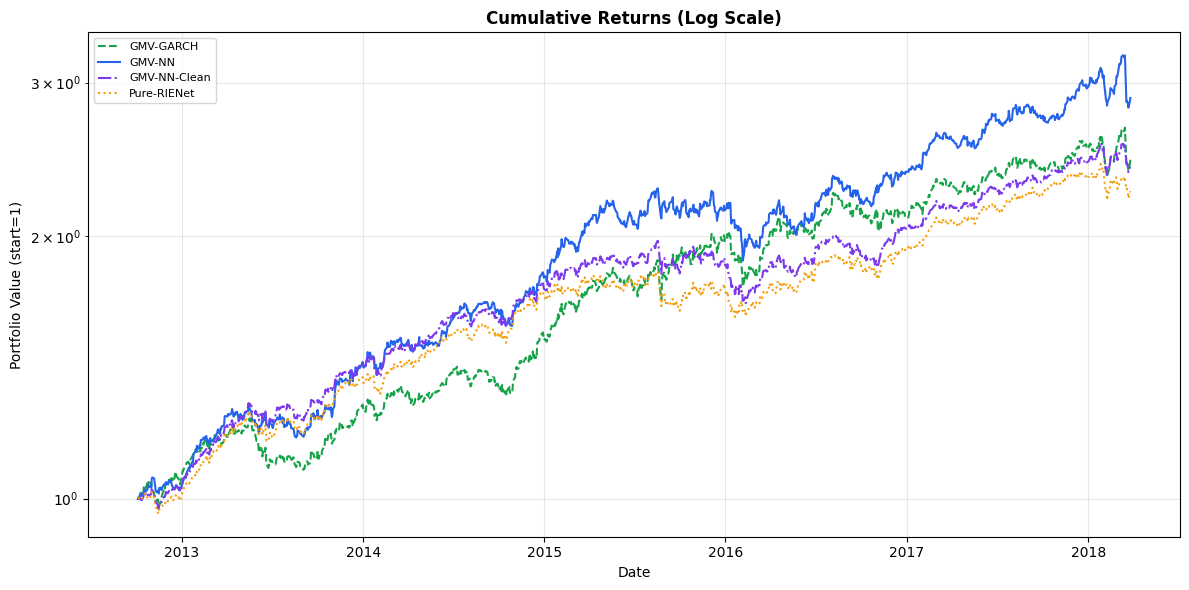

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))

for name, (r, _, col, ls) in strategies.items():
    cum = (1 + pd.Series(r, index=test_dates)).cumprod()
    ax.plot(cum.index, cum.values, color=col, linestyle=ls, linewidth=1.5, label=name)

ax.set_yscale('log')
ax.set_title('Cumulative Returns (Log Scale)', fontweight='bold')
ax.set_ylabel('Portfolio Value (start=1)')
ax.set_xlabel('Date')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which='both')

plt.tight_layout()
fig.savefig('cumulative_returns_log.png', dpi=150, bbox_inches='tight')
plt.show()
